***
# **<center>EXERCICES PYTHON 2IMACS #10</center>**
# ***<center>Machine Learning – Prédiction de la qualité d'un vin</center>***
***

## Contexte

Vous disposez du dataset **WineQT**, qui contient des caractéristiques physico-chimiques de vins portugais "Vinho Verde" et une note de qualité attribuée par des experts.

L'objectif est de construire un modèle de **classification binaire** capable de prédire si un vin est de "bonne qualité" à partir de ses seules mesures chimiques.

Vous utiliserez deux approches vues en cours :
- **Régression Logistique** (Scikit-Learn)
- **Réseau de neurones** (Keras / TensorFlow)

---

## Partie 1 — Exploration et préparation des données


### Question 1 — Chargement et premier aperçu

Chargez le fichier CSV `WineQT.csv` avec **pandas**.

**1-** Affichez les 5 premières lignes pour comprendre la structure du dataset.  
**2-** Affichez les **statistiques descriptives**. (nombre d'occurences, moyenne, écart-type, etc.) ?


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../fichiers_cours/pandas/WineQT.csv')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [25]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1139.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311765,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.749462,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


### Question 2 — Nettoyage et création de la variable cible

Le dataset contient une colonne `Id` (identifiant sans pouvoir prédictif) et des lignes avec valeurs manquantes.

**1**- Supprimez la colonne `Id`.  
**2**- Supprimez les lignes avec des **valeurs manquantes**.  
**3**- Créez une nouvelle colonne `good_quality` : vaut **1** si `quality ≥ 6`, **0** sinon. Cette colonne sera notre variable cible.  
**4**- Affichez la répartition des classes (combien de "bons" vins vs "mauvais") avec `value_counts()`.  


In [26]:
#1- Suppression de la colonne 'Id' (identifiant unique sans intérêt pour la modélisation)
df = df.drop('Id', axis=1)

#2- Suppression des lignes avec valeurs manquantes
df.dropna(inplace=True)
print('Dimensions après nettoyage :', df.shape)

#3- Création de colonne good_quality : 1 si quality >= 6, sinon 0
df['good_quality'] = (df['quality'] >= 6).astype(int)

#4- Répartition des classes
print(df['good_quality'].value_counts())

df.head()


Dimensions après nettoyage : (1139, 12)
good_quality
1    617
0    522
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


### Question 3 — Séparation des caractéristiques (X) et de la cible (Y)

**1-** Placez la colonne `good_quality` dans un dataframe `Y`.  
**2-** Placez toutes les autres colonnes **sauf** `quality` et `good_quality` dans un dataframe `X`.    
  (La colonne `quality` doit être exclue : elle est la source directe de `good_quality` et causerait une fuite d'information.)  
**3-** Affichez les dimensions de `X` et la liste de ses colonnes.  


In [27]:
#1- Placer la colonne 'good_quality' dans Y
Y = df['good_quality']
#2 - Placer les autres colonnes dans X
X = df.drop(columns=['quality', 'good_quality'])
#3- Afficher les dimensions de X et la liste de ses colonnes
print('Dimensions de X :', X.shape)
print('Colonnes :', X.columns.tolist())

Dimensions de X : (1139, 11)
Colonnes : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [28]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [29]:
# to_frame permet de convertir une Series en DataFrame (pour l'affichage du nom de la colonne)
Y.to_frame().head()

,good_quality
0,0
1,0
2,0
3,1
4,0


### Question 4 — Découpage Train / Test

**1-** Divisez les données en un jeu d'entraînement (80 %) et un jeu de test (20 %) avec `train_test_split`.    
Utilisez `random_state=42` pour des résultats reproductibles. 

**2-** Affichez les dimensions de `X_train` et `X_test`.


In [12]:
from sklearn.model_selection import train_test_split
#1- Divisez les données en un jeu d'entraînement
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
#2- Affichez les dimensions de `X_train` et `X_test`
print('X_train :', X_train.shape)
print('X_test  :', X_test.shape)


X_train : (911, 11)
X_test  : (228, 11)


### Question 5 — Standardisation des données

Regardez les statistiques de la Question 1 : `total sulfur dioxide` peut atteindre ~300, tandis que `chlorides` reste proche de 0.6.  
Les algorithmes basés sur les distances (et la régression logistique) sont sensibles à ces différences d'échelle.

**1-** Appliquer les standardisations suivantes :
- Sur ``X_train`` : utilisez ``fit_transform()`` pour calculer la moyenne/écart-type et appliquer la normalisation.
- Sur ``X_test`` : utilisez seulement ``transform()`` pour appliquer la même normalisation.

Attention : N'utilisez JAMAIS ``fit()`` ou ``fit_transform()`` sur ``X_test`` — vous "tricheriez" en laissant le modèle voir les informations du test. C'est ce qu'on appelle une fuite de données (data leakage).

**2-** Vérifiez que les données ont bien été standardisées en affichant la moyenne et l'écart-type de chaque colonne de ``X_train_scaled`` et ``X_test_scaled``.


In [13]:
from sklearn.preprocessing import StandardScaler
#1 Appliquer les standardisations
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [19]:
#2- Vérifiez que les données ont bien été standardisée
moyenne_train = np.mean(X_train_scaled, axis=0)
ecart_type_train = np.std(X_train_scaled, axis=0)
print('Moyenne de X_train_scaled :', moyenne_train)
print('Écart-type de X_train_scaled :', ecart_type_train)

Moyenne de X_train_scaled : [ 3.95829241e-16 -2.21313393e-16  7.40961140e-17  1.48192228e-16
  2.37887524e-16  3.16858382e-17  2.33987729e-17  6.95899004e-14
  9.20351732e-16  5.21597645e-16  1.40782617e-15]
Écart-type de X_train_scaled : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [20]:
moyenne_test = np.mean(X_test_scaled, axis=0)
ecart_type_test = np.std(X_test_scaled, axis=0)
print('Moyenne de X_test_scaled :', moyenne_test)
print('Écart-type de X_test_scaled :', ecart_type_test)

Moyenne de X_test_scaled : [ 0.03943676  0.1205073   0.04476512  0.02642249 -0.03662378  0.00416625
  0.07923022  0.08099837  0.0464503   0.0184862  -0.05595044]
Écart-type de X_test_scaled : [1.02249071 1.13391414 0.99988921 0.92712875 0.7486889  1.00738842
 1.0267153  1.05305863 1.03885274 1.05588622 1.03157696]


---

## Partie 2 — Modèle avec Scikit-Learn

### Question 6 — Entraînement d'une régression logistique

**1-** Créez un modèle `LogisticRegression` avec `max_iter=1000` et `random_state=42`.  
**2-** Entraînez-le sur les données d'entraînement standardisées.


In [22]:
from sklearn.linear_model import LogisticRegression

#1- Créez un modèle LogisticRegression avec max_iter=1000 et random_state=42.
lr_model = LogisticRegression(max_iter=1000, random_state=42)
#2- Entraînez-le sur les données d'entraînement standardisées.
lr_model.fit(X_train_scaled, Y_train)


LogisticRegression(max_iter=1000, random_state=42)

### Question 7 — Évaluation du modèle

**1-** Réalisez les prédictions sur le jeu de test.
**2-** Calculez et affichez l'**accuracy**.
**3-** Affichez la **matrice de confusion** avec `seaborn`. 


Accuracy (régression logistique) : 81.14%


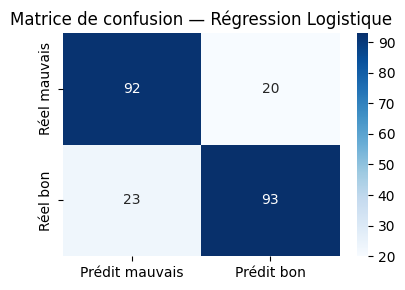

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix
#1- Réalisez les prédictions sur le jeu de test.
Y_pred_lr = lr_model.predict(X_test_scaled)
#2- Calculez et affichez l'**accuracy**.
print(f'Accuracy (régression logistique) : {accuracy_score(Y_test, Y_pred_lr)*100:.2f}%')
#3- Affichez la matrice de confusion
conf_matrix = confusion_matrix(Y_test, Y_pred_lr)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit mauvais', 'Prédit bon'],
            yticklabels=['Réel mauvais', 'Réel bon'], ax=ax)
ax.set_title('Matrice de confusion — Régression Logistique')
plt.tight_layout()
plt.show()


---

## Partie 3 — Réseau de neurones avec Keras / TensorFlow

### Question 8 — Architecture du réseau

Utilisez exactement l'architecture suivante :

- `Dense(64, activation='relu')`
- `Dense(64, activation='relu')`
- `Dense(1, activation='sigmoid')`

avec `input_shape=(X_train_scaled.shape[1],)` sur la première couche.

Ici on utilise `sigmoid` et non `softmax` car le problème a été transformé en **classification binaire** : le modèle ne doit distinguer que deux classes, "bon vin" ou "mauvais vin".

Affichez le résumé du modèle avec `model.summary()`.

In [32]:
import tensorflow as tf

nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

nn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,993 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

### Question 9 — Compilation et entraînement

**1-** **Compilez** le modèle avec :
  - `optimizer='adam'`
  - `loss='binary_crossentropy'`
  - `metrics=['accuracy']`  

**2-** **Entraînez** sur 20 epochs avec `batch_size=32` et `validation_split=0.2` et stockez le résultat dans une variable `history`.    

In [33]:
#1- Compilez le modèle
nn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
#2- Entraînez sur 20 epochs et stockez le résultat dans une variable `history`
history = nn_model.fit(X_train_scaled, Y_train,
                       epochs=20,
                       batch_size=32,
                       validation_split=0.2)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5800 - loss: 0.6762 - val_accuracy: 0.6776 - val_loss: 0.6053
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7865 - loss: 0.5491 - val_accuracy: 0.6995 - val_loss: 0.5775
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7307 - loss: 0.5334 - val_accuracy: 0.7049 - val_loss: 0.5547
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7708 - loss: 0.5071 - val_accuracy: 0.7213 - val_loss: 0.5486
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7589 - loss: 0.5012 - val_accuracy: 0.7213 - val_loss: 0.5477
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7627 - loss: 0.4955 - val_accuracy: 0.7213 - val_loss: 0.5492
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7606 - loss: 0.4803 - val_accuracy: 0.7322 - val_loss: 0.5525
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7655 - loss: 0.4798 - val_accuracy: 0.7377 - val_loss

### Question 10 — Évaluation finale et courbes d'apprentissage

**1-** Tracez les courbes de **loss** et d'**accuracy** pour l'entraînement et la validation.  
  Observez-vous un **surapprentissage** (overfitting) : les courbes de validation se dégradent-elles alors que l'entraînement continue de s'améliorer ?   
**2-** **Évaluez** le réseau sur `X_test_scaled` et **comparez** l'accuracy obtenue avec celle de la régression logistique (Question 7).  
  Le réseau de neurones apporte-t-il une amélioration significative sur ce dataset ?


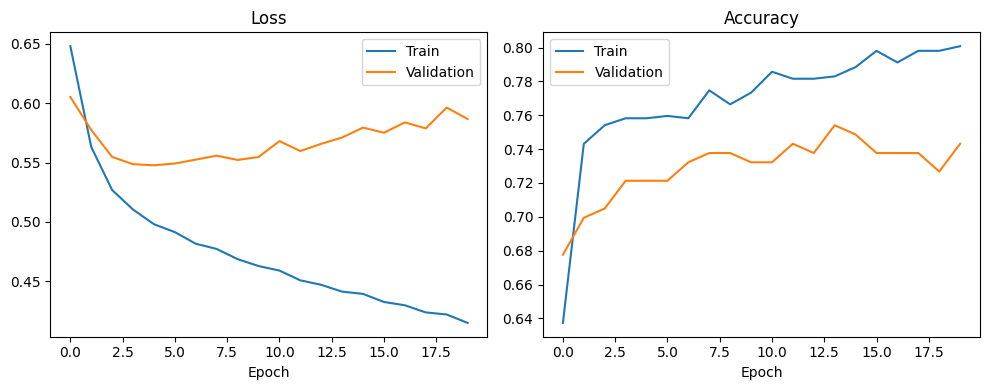

Accuracy réseau de neurones  : 80.70%
Accuracy régression logistique : 81.14%


In [34]:
# 1- Tracez les courbes de **loss** et d'**accuracy** pour l'entraînement et la validation.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2- **Évaluez** le réseau sur `X_test_scaled` 
loss_nn, acc_nn = nn_model.evaluate(X_test_scaled, Y_test, verbose=0)
print(f'Accuracy réseau de neurones  : {acc_nn*100:.2f}%')
print(f'Accuracy régression logistique : {accuracy_score(Y_test, Y_pred_lr)*100:.2f}%')


Vous savez maintenant construire un pipeline complet de machine learning, de la préparation des données à l'évaluation finale, en utilisant à la fois des méthodes classiques (régression logistique) et des réseaux de neurones. Vous pouvez, si vous le désirez utiliser le même pipeline pour d'autres modèles (SVM, Random Forest, etc.) 

---
---

# **Exercice 2 — Classification d'images : Fashion-MNIST**

## Contexte

**Fashion-MNIST** est un dataset de référence en vision par ordinateur, proposé par Zalando comme alternative plus difficile au MNIST des chiffres.  
Il contient **70 000 images en niveaux de gris** (28×28 pixels) réparties en **10 catégories de vêtements** :

| Label | Catégorie       |
|-------|-----------------|
| 0     | T-shirt / Top   |
| 1     | Pantalon        |
| 2     | Pull            |
| 3     | Robe            |
| 4     | Manteau         |
| 5     | Sandale         |
| 6     | Chemise         |
| 7     | Sneaker         |
| 8     | Sac             |
| 9     | Bottine         |

Le dataset est **directement intégré dans Keras** — aucun téléchargement manuel n'est nécessaire.

L'objectif est de construire un réseau de neurones capable de reconnaître automatiquement la catégorie d'un vêtement à partir de son image.

---

## Partie 1 — Chargement et exploration des données


### Question 1 — Chargement et visualisation

Chargez le dataset Fashion-MNIST avec `tf.keras.datasets.fashion_mnist.load_data()`.

**1-** Affichez les dimensions de `X_train`, `X_test`, `Y_train`, `Y_test`.  
**2-** Quelle est la plage de valeurs des pixels ?  
**3-** Affichez une grille de 5×10 images (une colonne par catégorie, plusieurs exemples par catégorie) avec les noms des catégories en titre de colonne.

In [35]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

#1- Chargement du dataset
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.fashion_mnist.load_data()

#2 et 3- Affichez les dimensions et la plage de valeurs
print('X_train :', X_train.shape, '  Y_train :', Y_train.shape)
print('X_test  :', X_test.shape,  '  Y_test  :', Y_test.shape)
print('Plage de valeurs pixels : min =', X_train.min(), ', max =', X_train.max())


X_train : (60000, 28, 28)   Y_train : (60000,)
X_test  : (10000, 28, 28)   Y_test  : (10000,)
Plage de valeurs pixels : min = 0 , max = 255


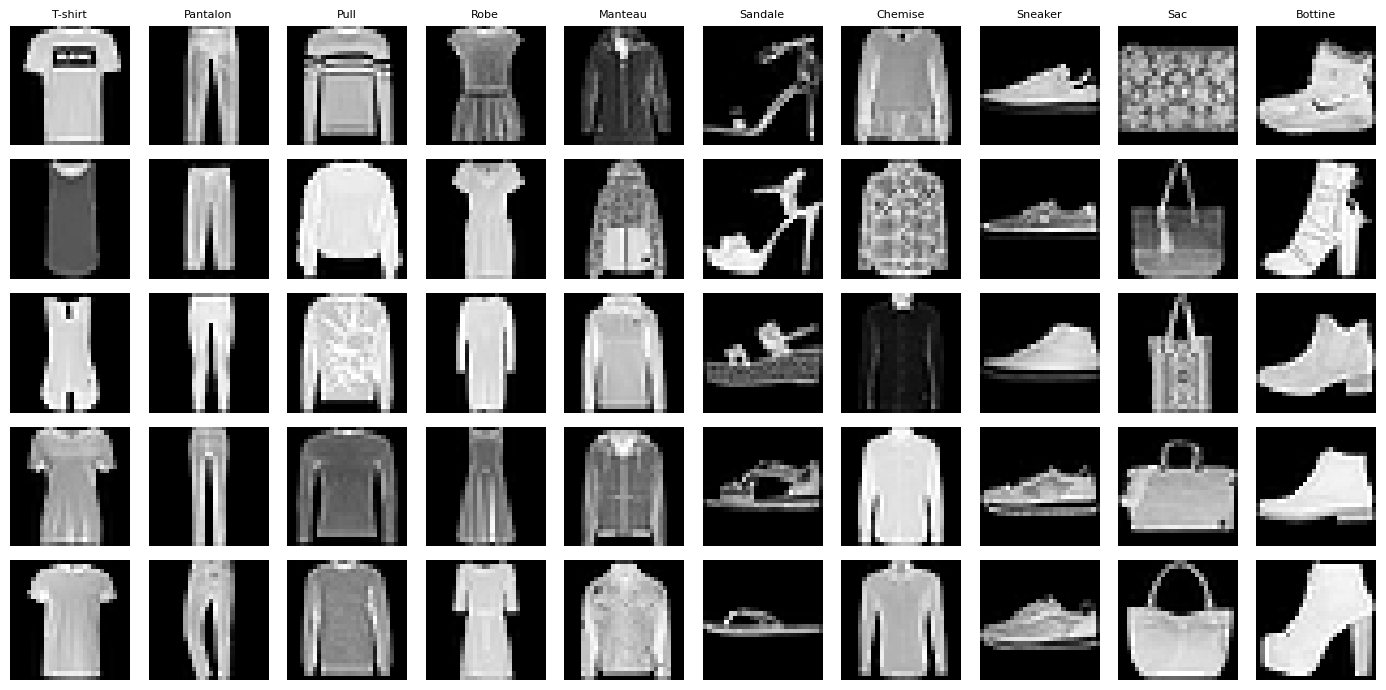

In [36]:
class_names = ['T-shirt', 'Pantalon', 'Pull', 'Robe', 'Manteau',
               'Sandale', 'Chemise', 'Sneaker', 'Sac', 'Bottine']

#3- Afficher grille 5×10 (une colonne par catégorie)
fig, axes = plt.subplots(5, 10, figsize=(14, 7))
for col, cls in enumerate(range(10)):
    idx = np.where(Y_train == cls)[0][:5]  # 5 premiers exemples de la classe
    for row, i in enumerate(idx):
        axes[row, col].imshow(X_train[i], cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(class_names[cls], fontsize=8)
plt.tight_layout()
plt.show()


### Question 2 — Normalisation

Les pixels ont des valeurs entières entre 0 et 255.

**1-** Normalisez les images avec **StandardScaler** après avoir aplati les images.  
**2-** Recréez ensuite la forme 28×28.  
**3-** Vérifiez que la normalisation donne une moyenne globale proche de 0 et un écart-type proche de 1.

In [37]:
from sklearn.preprocessing import StandardScaler

#1- Aplatir les images et standardiser avec StandardScaler
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

scaler_img = StandardScaler()
X_train_norm = scaler_img.fit_transform(X_train_flat).reshape(X_train.shape)
#2- Recréer la forme 28×28
X_test_norm  = scaler_img.transform(X_test_flat).reshape(X_test.shape)

#3- Vérifier la normalisation (moyenne ~0, écart-type ~1)
print('Moyenne globale ~', round(float(X_train_norm.mean()), 4))
print('Ecart-type global ~', round(float(X_train_norm.std()), 4))
print('Min :', round(float(X_train_norm.min()), 3), '  Max :', round(float(X_train_norm.max()), 3))

Moyenne globale ~ -0.0
Ecart-type global ~ 1.0
Min : -2.41   Max : 185.478


---

## Partie 2 — Construction et entraînement du réseau

### Question 3 — Architecture du réseau

Construisez un modèle `tf.keras.Sequential` en vous inspirant du cours MNIST.

Pour garder la même logique que dans le cours, définissez d'abord deux variables `hidden1` et `hidden2` (par exemple 128 et 128), puis utilisez-les dans les couches cachées.

- Une couche `Flatten` pour transformer l'image 28×28 en un vecteur de 784 valeurs.
- Deux couches cachées `Dense(hidden1, activation='relu')` et `Dense(hidden2, activation='relu')`.
- Une couche de sortie `Dense(10, activation='softmax')` — 10 neurones car il y a 10 catégories.

Affichez le résumé avec `model.summary()` et vérifiez le nombre de paramètres.

In [38]:
# Definition des couches cachées
hidden1 = 128
hidden2 = 128

# Construction du modèle
fashion_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(hidden1, activation='relu'),
    tf.keras.layers.Dense(hidden2, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
# Affichage de la structure du modèle
fashion_model.summary()

c:\Users\cayez\Documents\DONNEES_SIMON\python_env\donnees\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

### Question 4 — Compilation et entraînement

**1-** Compilez avec `optimizer='adam'`, `loss='sparse_categorical_crossentropy'`, `metrics=['accuracy']`.  
**2-** Entraînez sur **20 epochs**, `batch_size=256`, `validation_split=0.1` et stockez le résultat dans `history`.

In [39]:
#1- Compiler le modèle
fashion_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

#2- Entraîner sur 20 epochs et stocker dans history
history = fashion_model.fit(X_train_norm, Y_train,
                            epochs=20,
                            batch_size=256,
                            validation_split=0.1)


Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7652 - loss: 0.6691 - val_accuracy: 0.8670 - val_loss: 0.3621
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8761 - loss: 0.3422 - val_accuracy: 0.8770 - val_loss: 0.3381
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8944 - loss: 0.2894 - val_accuracy: 0.8822 - val_loss: 0.3248
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9065 - loss: 0.2596 - val_accuracy: 0.8777 - val_loss: 0.3267
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9115 - loss: 0.2398 - val_accuracy: 0.8815 - val_loss: 0.3262
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9171 - loss: 0.2225 - val_accuracy: 0.8832 - val_loss: 0.3160
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9261 - loss: 0.2026 - val_accuracy: 0.8908 - val_loss: 0.3079
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9327 - loss: 0.1822 - val_accuracy: 0.

---

## Partie 3 — Évaluation et interprétation

### Question 5 — Accuracy et courbes d'apprentissage

**1-** Évaluez le modèle sur le jeu de test et affichez l'**accuracy**.  
**2-** Tracez les courbes de **loss** et d'**accuracy** (train et validation).  


Accuracy sur le jeu de test : 88.45%


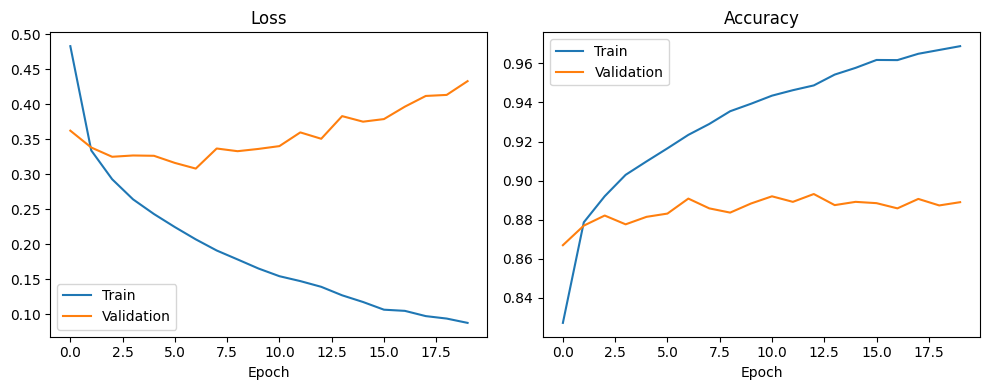

In [40]:
#1- Évaluer sur le jeu de test et afficher l'accuracy
loss_test, acc_test = fashion_model.evaluate(X_test_norm, Y_test, verbose=0)
print(f'Accuracy sur le jeu de test : {acc_test*100:.2f}%')

#2- Tracer les courbes de loss et accuracy
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


### Question 6 — Matrice de confusion

**1-** Calculez les prédictions sur le jeu de test avec `np.argmax`.  
**2-** Affichez la **matrice de confusion 10×10** avec `seaborn`, en utilisant les noms des catégories comme labels.  
**3-** Identifiez les catégories les plus souvent confondues entre elles. Cela vous semble-t-il logique visuellement ?

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step


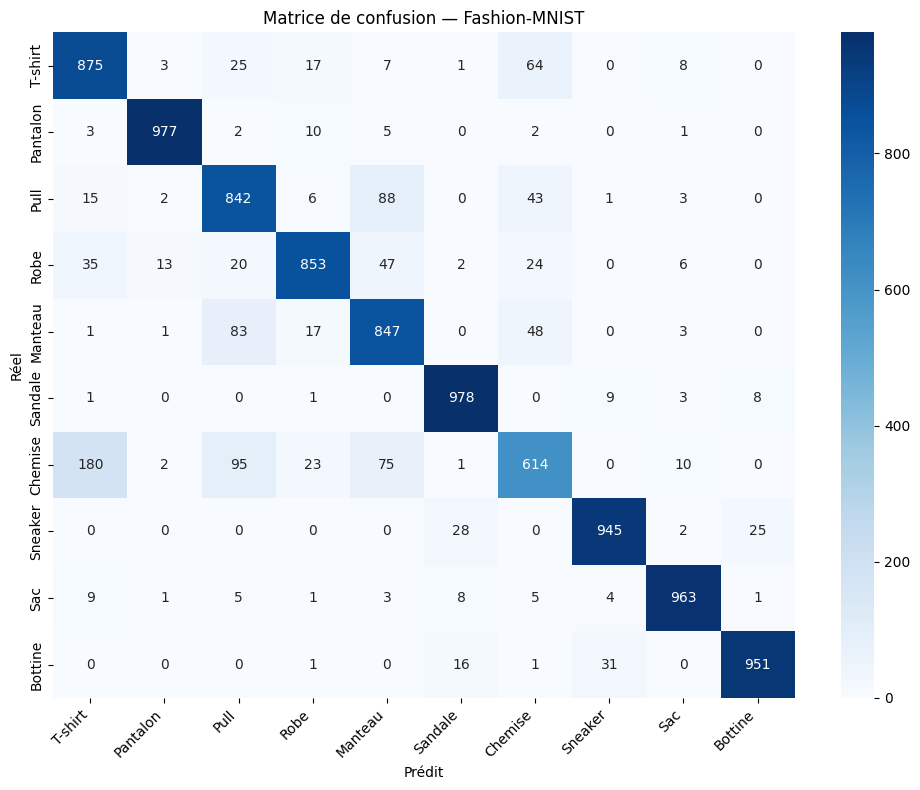

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# 1 calculer les prédictions sur le jeu de test
Y_pred_proba = fashion_model.predict(X_test_norm)
Y_pred       = np.argmax(Y_pred_proba, axis=1)

#
conf_matrix = confusion_matrix(Y_test, Y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion — Fashion-MNIST')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Question 7 — Visualisation des erreurs

Affichez une grille de **16 images mal classifiées** en indiquant pour chacune la vraie catégorie et la catégorie prédite.  
Cela permet de comprendre qualitativement pourquoi le modèle se trompe.


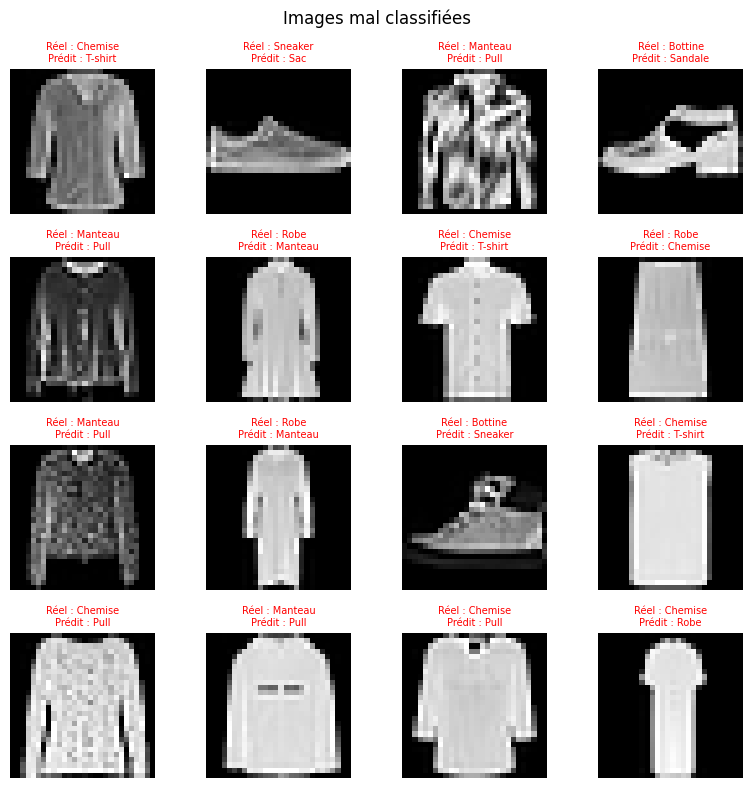

In [42]:
wrong_idx = np.where(Y_pred != Y_test)[0]
sample    = wrong_idx[:16]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, i in zip(axes.flat, sample):
    ax.imshow(X_test[i], cmap='gray')
    ax.set_title(f'Réel : {class_names[Y_test[i]]}\nPrédit : {class_names[Y_pred[i]]}',
                 fontsize=7, color='red')
    ax.axis('off')
plt.suptitle('Images mal classifiées', fontsize=12)
plt.tight_layout()
plt.show()
